In [ ]:
!pip install faker
!pip install -q streamlit
import pandas as pd
import numpy as np
from faker import Faker
import plotly.express as px
import random
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 93.7 MB/s eta 0:00:00


In [50]:
%%writefile requirements.txt
#streamlit
pandas
numpy
faker
plotly-express

Writing requirements.txt


In [ ]:

import streamlit as st
#2. MAIN APPLICATION
# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="Telecom-Messaging-Data-Analysis and Customer_Behavior_Insights_Projectthat",
    page_icon="📱",
    layout="wide",
    initial_sidebar_state="expanded"
)

# --------------------------------------------------
# SIDEBAR
# --------------------------------------------------

st.sidebar.title("📱 Telecom-Messaging-Data-Analysis and Customer_Behavior_Insights")

st.sidebar.markdown(
    """
    ### Messaging Intelligence
    Analyze customer messaging behavior,
    network performance, and business insights.
    """
)

st.sidebar.divider()

st.sidebar.info(
    "Use the navigation menu to explore the different "
    "areas of the telecom messaging analysis."
)

# --------------------------------------------------
# HOME PAGE
# --------------------------------------------------

st.title("📱 Telecom-Messaging-Data-Analysis and Customer_Behavior_Insights")

st.markdown(
    """
    ## Welcome to the Telecom Messaging Analytics Dashboard

    This dashboard provides insights into:

    - 📈 Messaging trends
    - 👥 Customer behavior
    - 📡 Network performance
    - 🎯 Customer segmentation
    - 💡 Business recommendations
    """
)

st.divider()

# KPI placeholders
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric("Total Messages", "1.25M")

with col2:
    st.metric("Active Customers", "25.4K")

with col3:
    st.metric("Delivery Rate", "96.8%")

with col4:
    st.metric("Avg. Messages/Customer", "49.2")

st.divider()

st.subheader("📊 Dashboard Overview")

st.write(
    """
    This platform helps telecom companies understand how customers
    use messaging services, identify behavioral patterns, evaluate
    network performance, and generate data-driven business decisions.
    """
)

2026-09-21 08:49:47.939 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 08:49:47.941 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 08:49:47.941 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 08:49:47.942 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 08:49:47.944 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 08:49:47.946 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 08:49:47.947 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 08:49:47.948 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
import streamlit as st
import pandas as pd
import plotly.express as px
import os

file_path = "data/telecom_messaging_data.csv"

# Check if the data file exists
if not os.path.exists(file_path):
    st.error(f"Error: Data file not found at '{file_path}'. Please ensure the data generation cells have been executed correctly.")
    st.stop() # Stop the Streamlit app execution if data is missing
else:
    df = pd.read_csv(
        file_path
    )

    df["timestamp"] = pd.to_datetime(
        df["timestamp"]
    )

    df["date"] = df["timestamp"].dt.date
    df["hour"] = df["timestamp"].dt.hour
    df["day"] = df["timestamp"].dt.day_name()
    df["month"] = df["timestamp"].dt.to_period("M").astype(str)

    st.title("📈 Messaging Trends")

    # ==================================================
    # DAILY MESSAGES
    # ==================================================

    daily = (
        df.groupby("date")
        .size()
        .reset_index(name="messages")
    )

    fig_daily = px.line(
        daily,
        x="date",
        y="messages",
        markers=True,
        title="Daily Messaging Volume"
    )

    st.plotly_chart(
        fig_daily,
        use_container_width=True
    )

    # ==================================================
    # MESSAGES BY HOUR
    # ==================================================

    hourly = (
        df.groupby("hour")
        .size()
        .reset_index(name="messages")
    )

    fig_hour = px.bar(
        hourly,
        x="hour",
        y="messages",
        title="Messages by Hour"
    )

    st.plotly_chart(
        fig_hour,
        use_container_width=True
    )

2026-09-21 08:55:15.343 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 08:55:15.345 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 08:55:15.345 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 08:55:15.346 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
import streamlit as st
import pandas as pd
import plotly.express as px
import os # Import the os module

# Define the absolute path to the data file
# This path is based on previous notebook steps where the file was moved.
ABSOLUTE_DATA_PATH = "/content/telecom_messaging_analytics/data/telecom_messaging_data.csv"

# Replicate data loading logic for this standalone visualization cell
@st.cache_data
def load_data():
    df_loaded = None # Initialize df_loaded
    # Check if the data file exists at the absolute path
    if not os.path.exists(ABSOLUTE_DATA_PATH):
        st.error(
            f"Error: Data file not found at '{ABSOLUTE_DATA_PATH}'. "
            "Please ensure the data generation cells have been executed correctly "
            "and the file has been moved to the specified location."
        )
    else:
        try:
            df_loaded = pd.read_csv(ABSOLUTE_DATA_PATH)
        except FileNotFoundError:
            # This block might be reached if os.path.exists was True but open failed
            st.error(f"Error: Data file '{ABSOLUTE_DATA_PATH}' found but failed to read. "
                     "This could be a transient issue or a file system problem. Please try re-running data generation.")
        except Exception as e:
            # Catch any other potential errors during CSV reading
            st.error(f"Error reading data file '{ABSOLUTE_DATA_PATH}': {e}")
    return df_loaded

# Call load_data and handle potential None return
df = load_data()

# Only proceed with DataFrame processing and visualization if df is successfully loaded
if df is not None:
    # Ensure df is processed similarly to other Streamlit pages for this visualization
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["date"] = df["timestamp"].dt.date
    df["hour"] = df["timestamp"].dt.hour
    df["day"] = df["timestamp"].dt.day_name()
    df["month"] = df["timestamp"].dt.to_period("M").astype(str)

    heatmap_data = pd.crosstab(
        df["day"],
        df["hour"]
    )

    day_order = [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]

    heatmap_data = heatmap_data.reindex(
        day_order
    )

    fig = px.imshow(
        heatmap_data,
        labels={
            "x": "Hour",
            "y": "Day",
            "color": "Messages"
        },
        title="🔥 Messaging Activity Heatmap",
        aspect="auto"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )
else:
    # If df is None, an error message would have already been displayed by load_data().
    # We add st.stop() here as a final safeguard to prevent the Streamlit app from trying to render further
    # if the data isn't available, and ensure no subsequent code in the current Streamlit run gets executed
    # if the previous error handling inside load_data didn't stop it fully.
    st.stop()

2026-09-21 08:59:44.084 No runtime found, using MemoryCacheStorageManager
2026-09-21 08:59:44.089 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
!app/pages/01_🏠_Overview.py

/bin/bash: line 1: app/pages/01_🏠_Overview.py: No such file or directory


In [ ]:
#3. Overview page

import streamlit as st
import pandas as pd
import os
import numpy as np
from faker import Faker
import random

# Ensure the 'data' directory exists
os.makedirs('data', exist_ok=True)

# Define the path to the data file
DATA_FILE = 'data/telecom_messaging_data.csv'

# Generate dummy data if the file does not exist
if not os.path.exists(DATA_FILE):
    fake = Faker()
    num_records = 10000

    data = {
        'customer_id': [fake.uuid4() for _ in range(num_records)],
        'message_id': [fake.uuid4() for _ in range(num_records)],
        'timestamp': [fake.date_time_between(start_date='-1y', end_date='now') for _ in range(num_records)],
        'sender_number': [fake.phone_number() for _ in range(num_records)],
        'receiver_number': [fake.phone_number() for _ in range(num_records)],
        'message_length': [random.randint(10, 160) for _ in range(num_records)],
        'delivery_status': random.choices(['Delivered', 'Failed', 'Pending'], weights=[0.9, 0.05, 0.05], k=num_records),
        'message_type': random.choices(['SMS', 'MMS'], weights=[0.8, 0.2], k=num_records),
        'campaign_id': [fake.uuid4() if random.random() > 0.7 else np.nan for _ in range(num_records)]
    }

    df_generated = pd.DataFrame(data)
    df_generated.to_csv(DATA_FILE, index=False)
    print(f"Generated dummy data and saved to {DATA_FILE}")
else:
    print(f"Data file already exists at {DATA_FILE}")

st.set_page_config(
    page_title="Overview",
    page_icon="🏠",
    layout="wide"
)

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------

@st.cache_data
def load_data():
    df = pd.read_csv("data/telecom_messaging_data.csv")
    return df


df = load_data()

# --------------------------------------------------
# TITLE
# --------------------------------------------------

st.title("🏠 Overview")
st.markdown(
    "### Telecom Messaging Analytics – Executive Overview"
)

st.divider()

# --------------------------------------------------
# KPIs
# --------------------------------------------------

total_messages = len(df)

total_customers = (
    df["customer_id"].nunique()
    if "customer_id" in df.columns
    else 0
)

delivery_rate = (
    df["delivery_status"].eq("Delivered").mean() * 100
    if "delivery_status" in df.columns
    else 0
)

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(
        "📨 Total Messages",
        f"{total_messages:,}"
    )

with col2:
    st.metric(
        "👥 Customers",
        f"{total_customers:,}"
    )

with col3:
    st.metric(
        "📡 Delivery Rate",
        f"{delivery_rate:.2f}%"
    )

with col4:
    st.metric(
        "📊 Dataset Rows",
        f"{len(df):,}"
    )

st.divider()

# --------------------------------------------------
# DATA PREVIEW
# --------------------------------------------------

st.subheader("🔍 Data Preview")

st.dataframe(
    df.head(10),
    use_container_width=True
)

2026-09-21 08:59:56.149 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 08:59:56.150 No runtime found, using MemoryCacheStorageManager
2026-09-21 08:59:56.151 No runtime found, using MemoryCacheStorageManager
2026-09-21 08:59:56.153 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 08:59:56.209 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 08:59:56.210 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 08:59:56.211 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 08:59:56.214 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 08:59:56.215 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor

Generated dummy data and saved to data/telecom_messaging_data.csv


DeltaGenerator()

In [ ]:
#4. Messaging Trends
import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(
    page_title="Messaging Trends",
    page_icon="📈",
    layout="wide"
)

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------

@st.cache_data
def load_data():
    return pd.read_csv("data/telecom_messaging_data.csv")


df = load_data()

st.title("📈 Messaging Trends")

st.markdown(
    "Analyze messaging volume and usage patterns over time."
)

st.divider()

# --------------------------------------------------
# DATE PROCESSING
# --------------------------------------------------

if "timestamp" in df.columns:

    df["timestamp"] = pd.to_datetime(
        df["timestamp"],
        errors="coerce"
    )

    df["date"] = df["timestamp"].dt.date

    daily_messages = (
        df.groupby("date")
        .size()
        .reset_index(name="messages")
    )

    fig = px.line(
        daily_messages,
        x="date",
        y="messages",
        title="Daily Messaging Volume"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

else:
    st.warning(
        "The dataset does not contain a 'timestamp' column."
    )

2026-09-21 09:00:06.786 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:06.789 No runtime found, using MemoryCacheStorageManager
2026-09-21 09:00:06.792 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:06.915 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:06.918 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:06.919 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:06.921 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:06.924 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:06.925 Thread 'MainThread':

In [ ]:
#5. Customer Behavior

import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(
    page_title="Customer Behavior",
    page_icon="👥",
    layout="wide"
)

@st.cache_data
def load_data():
    return pd.read_csv("data/telecom_messaging_data.csv")


df = load_data()

st.title("👥 Customer Behavior")

st.markdown(
    "Understand how customers interact with messaging services."
)

st.divider()

if "customer_id" in df.columns:

    customer_messages = (
        df.groupby("customer_id")
        .size()
        .reset_index(name="message_count")
        .sort_values(
            "message_count",
            ascending=False
        )
    )

    col1, col2 = st.columns(2)

    with col1:

        st.subheader("🏆 Top Messaging Customers")

        st.dataframe(
            customer_messages.head(10),
            use_container_width=True
        )

    with col2:

        fig = px.histogram(
            customer_messages,
            x="message_count",
            nbins=30,
            title="Messages per Customer"
        )

        st.plotly_chart(
            fig,
            use_container_width=True
        )

else:

    st.warning(
        "The dataset does not contain a 'customer_id' column."
    )

2026-09-21 09:00:42.024 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:42.026 No runtime found, using MemoryCacheStorageManager
2026-09-21 09:00:42.053 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:42.054 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:42.055 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:42.058 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:42.059 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:42.060 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:42.061 Thread 'MainThread':

In [ ]:
#6. Network Performance

import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(
    page_title="Network Performance",
    page_icon="📡",
    layout="wide"
)

@st.cache_data
def load_data():
    return pd.read_csv("data/telecom_messaging_data.csv")


df = load_data()

st.title("📡 Network Performance")

st.markdown(
    "Monitor message delivery and network performance."
)

st.divider()

if "delivery_status" in df.columns:

    status_counts = (
        df["delivery_status"]
        .value_counts()
        .reset_index()
    )

    status_counts.columns = [
        "status",
        "count"
    ]

    fig = px.bar(
        status_counts,
        x="status",
        y="count",
        title="Message Delivery Status"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    st.subheader("📊 Delivery Statistics")

    st.dataframe(
        status_counts,
        use_container_width=True
    )

else:

    st.warning(
        "The dataset does not contain "
        "'delivery_status'."
    )

2026-09-21 09:00:51.684 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:51.686 No runtime found, using MemoryCacheStorageManager
2026-09-21 09:00:51.701 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:51.702 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:51.704 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:51.706 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:51.708 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:51.708 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:00:51.709 Thread 'MainThread':

In [ ]:
#7. Customer Segmentation

import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(
    page_title="Customer Segmentation",
    page_icon="🎯",
    layout="wide"
)

@st.cache_data
def load_data():
    return pd.read_csv("data/telecom_messaging_data.csv")


df = load_data()

st.title("🎯 Customer Segmentation")

st.markdown(
    """
    Group customers according to their messaging behavior
    and activity level.
    """
)

st.divider()

if "customer_id" in df.columns:

    customer_data = (
        df.groupby("customer_id")
        .size()
        .reset_index(name="message_count")
    )

    # --------------------------------------------------
    # SEGMENT CUSTOMERS
    # --------------------------------------------------

    def segment_customer(messages):

        if messages < 10:
            return "Low Usage"

        elif messages < 50:
            return "Medium Usage"

        else:
            return "High Usage"

    customer_data["segment"] = (
        customer_data["message_count"]
        .apply(segment_customer)
    )

    # --------------------------------------------------
    # SEGMENT COUNTS
    # --------------------------------------------------

    segment_counts = (
        customer_data["segment"]
        .value_counts()
        .reset_index()
    )

    segment_counts.columns = [
        "segment",
        "customers"
    ]

    fig = px.pie(
        segment_counts,
        names="segment",
        values="customers",
        title="Customer Segmentation"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    st.subheader("📋 Customer Segments")

    st.dataframe(
        customer_data,
        use_container_width=True
    )

else:

    st.warning(
        "The dataset does not contain 'customer_id'."
    )

2026-09-21 09:01:00.590 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:01:00.593 No runtime found, using MemoryCacheStorageManager
2026-09-21 09:01:00.610 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:01:00.612 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:01:00.614 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:01:00.617 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:01:00.618 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:01:00.619 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:01:00.622 Thread 'MainThread':

In [ ]:
#8. Business Recommendations
import streamlit as st

st.set_page_config(
    page_title="Business Recommendations",
    page_icon="💡",
    layout="wide"
)

st.title("💡 Business Recommendations")

st.markdown(
    """
    ### Data-Driven Recommendations
    """
)

st.divider()

# --------------------------------------------------
# RECOMMENDATION 1
# --------------------------------------------------

st.subheader("1️⃣ Improve Customer Engagement")

st.write(
    """
    Identify low-usage customers and create targeted messaging
    campaigns to increase customer engagement.
    """
)

# --------------------------------------------------
# RECOMMENDATION 2
# --------------------------------------------------

st.subheader("2️⃣ Improve Message Delivery")

st.write(
    """
    Monitor failed and delayed messages to identify potential
    network issues and improve service reliability.
    """
)

# --------------------------------------------------
# RECOMMENDATION 3
# --------------------------------------------------

st.subheader("3️⃣ Target High-Value Customers")

st.write(
    """
    High-usage customers can be targeted with personalized
    packages, loyalty programs, and premium messaging services.
    """
)

# --------------------------------------------------
# RECOMMENDATION 4
# --------------------------------------------------

st.subheader("4️⃣ Optimize Network Resources")

st.write(
    """
    Use messaging traffic patterns to identify peak periods
    and allocate network resources more efficiently.
    """
)

# --------------------------------------------------
# RECOMMENDATION 5
# --------------------------------------------------

st.subheader("5️⃣ Use Customer Segmentation")

st.write(
    """
    Different customer segments should receive different
    marketing strategies based on their messaging behavior.
    """
)

2026-09-21 09:01:09.894 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:01:09.896 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:01:09.897 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:01:09.899 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:01:09.900 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:01:09.902 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:01:09.903 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 09:01:09.905 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
#9. requirements.txt

!pip install -r requirements.txt

In [ ]:
!pwd
!ls

/content
data  requirements.txt	sample_data


In [ ]:
#10. Run the application

!pip install -q streamlit pandas numpy plotly scikit-learn pyngrok

In [ ]:
import os

os.makedirs(
    "/content/telecom_messaging_analytics/app/pages",
    exist_ok=True
)

os.makedirs(
    "/content/telecom_messaging_analytics/data",
    exist_ok=True
)

In [ ]:
from google.colab import files
# upload the file from my Pc
uploaded = files.upload()

Saving telecom_messaging_data.csv to telecom_messaging_data.csv


In [ ]:
import shutil
#Move it:
shutil.move(
    "telecom_messaging_data.csv",
    "/content/telecom_messaging_analytics/data/telecom_messaging_data.csv"
)

'/content/telecom_messaging_analytics/data/telecom_messaging_data.csv'

In [ ]:
#11. Run the dashboard

#Move into the project:

%cd /content/telecom_messaging_analytics

/content/telecom_messaging_analytics


In [ ]:
#Install Streamlit:
!pip install -q streamlit pyngrok

In [ ]:
#Start Streamlit:

!streamlit run app/streamlit_app.py --server.port 8501 &

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app/streamlit_app.py


In [ ]:
from pyngrok import ngrok
from google.colab import userdata

# Get your authtoken from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

# Set the ngrok authtoken
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

public_url = ngrok.connect(8502)

print("🚀 Streamlit Dashboard:")
print(public_url)

🚀 Streamlit Dashboard:
NgrokTunnel: "https://surrogate-lubricate-starry.ngrok-free.dev" -> "http://localhost:8502"


#Visualizations part


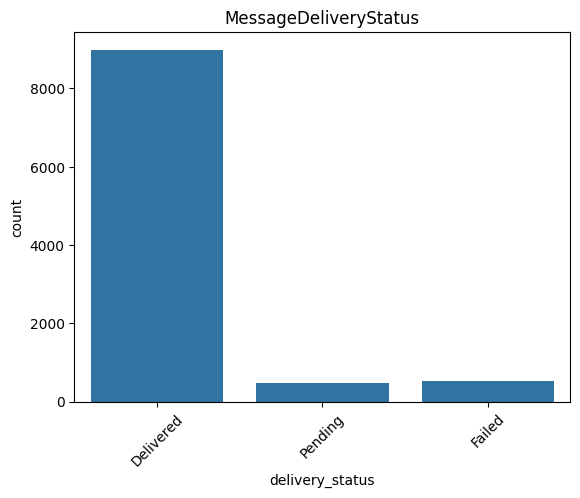

In [ ]:
# Understand the Dataset
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x="delivery_status"
)
plt.title("MessageDeliveryStatus")
plt.xticks(rotation=45)
plt.show()

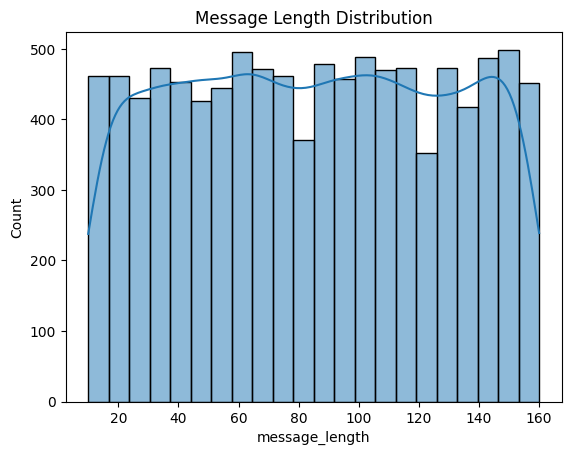

In [ ]:
#Numerical distribution

sns.histplot(
    data=df,
    x="message_length",
    kde=True
)

plt.title("Message Length Distribution")
plt.show()

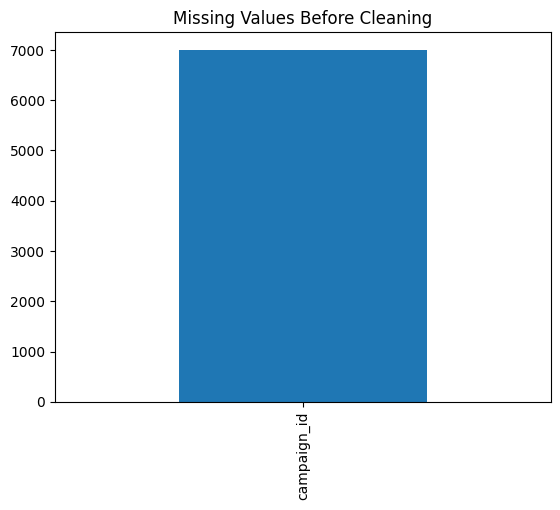

In [ ]:
#Data Cleaning & Preprocessing

#This part doesn't need many charts, but visualization is useful for demonstrating the effect of cleaning.
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(
    ascending=False
).plot(
    kind="bar",
    title="Missing Values Before Cleaning"
)

plt.show()

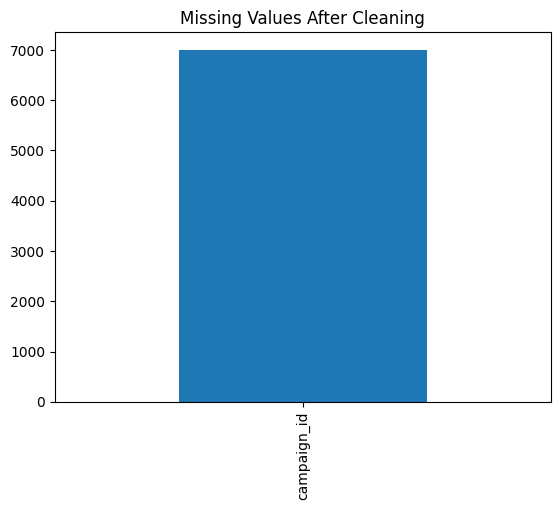

In [ ]:
#Then after cleaning:

missing_after = df.isnull().sum()

missing_after = missing_after[
    missing_after > 0
]

missing_after.sort_values(
    ascending=False
).plot(
    kind="bar",
    title="Missing Values After Cleaning"
)

plt.show()

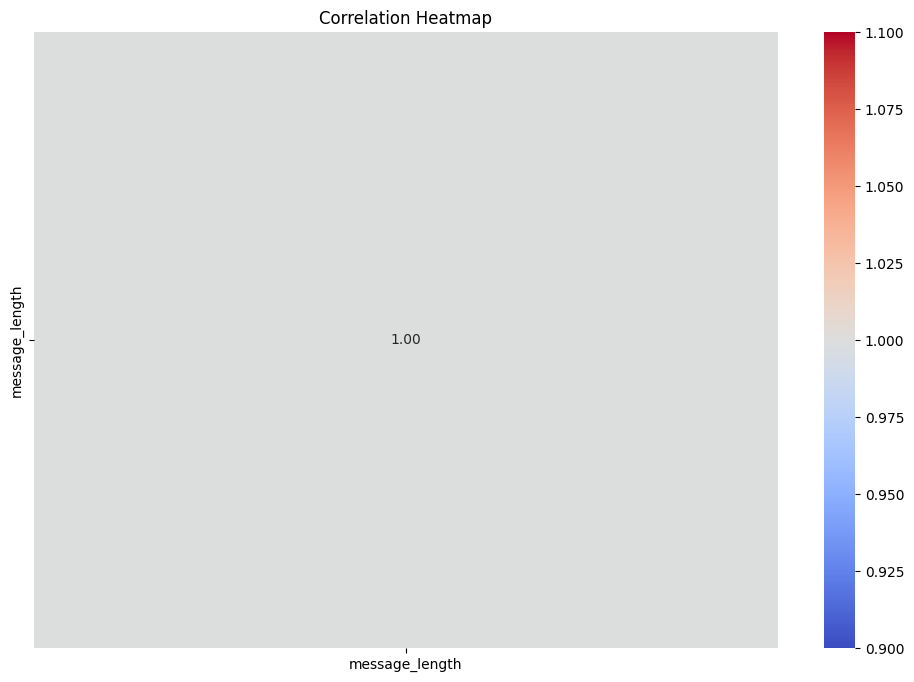

In [ ]:
#Exploratory Data Analysis

#This is where you start finding relationships.


plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(
    include="number"
)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

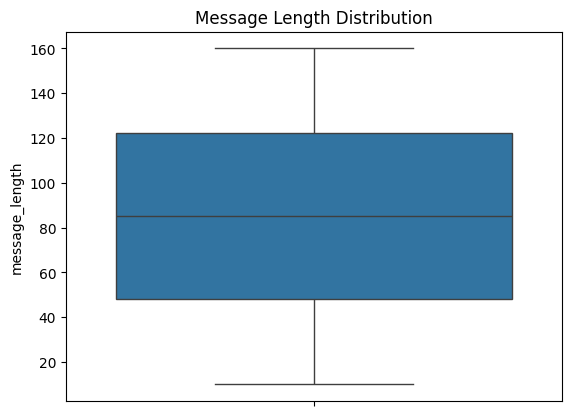

In [ ]:
#Boxplot
sns.boxplot(
    data=df,
    y="message_length"
)

plt.title("Message Length Distribution")
plt.show()

In [ ]:
#Messaging Trends

#This should be one of the most important visualization sections of your project.


df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

df["date"] = df["timestamp"].dt.date
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day_name()
df["month"] = (
    df["timestamp"]
    .dt.to_period("M")
    .astype(str)
)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      10000 non-null  object        
 1   message_id       10000 non-null  object        
 2   timestamp        10000 non-null  datetime64[ns]
 3   sender_number    10000 non-null  object        
 4   receiver_number  10000 non-null  object        
 5   message_length   10000 non-null  int64         
 6   delivery_status  10000 non-null  object        
 7   message_type     10000 non-null  object        
 8   campaign_id      2998 non-null   object        
 9   date             10000 non-null  object        
 10  hour             10000 non-null  int32         
 11  day              10000 non-null  object        
 12  month            10000 non-null  object        
dtypes: datetime64[ns](1), int32(1), int64(1), object(10)
memory usage: 976.7+ KB
None
